# 深度卷积神经网络（AlexNet）
---
## 环境配置

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import numpy as np
import pypto
import torch
import torch_npu
import torchvision
from torch import nn
device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
mode = pypto.RunMode.NPU
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d, PyPTOAvgPool2d
from src.PyPTOLinearFuseModule import PyPTOLinear
from src.PyPTODropoutModule import PyPTODropout
from src.D2LFunction import *
from src.AnswerUtlis import *
from src import Models
import torchinfo
pth = '../data/ch07_output/'

---

&emsp;&emsp;在本节练习中，我们分别用到了两种网络，分别是AlexNet以及LeNet，在进入练习之前，我们先给出两个模型的网络结构（此处只列举网络的层次结构，具体的网络定义我们封装在`models.py`文件当中）：\
&emsp;&emsp;首先对于AlexNet，其结构如下：

<div style="border: solid 16px #f1f1f8; text-align: center; background-color: #f6f7f9">
<img src="../images/ch07-1-1-alexnet.png" style="width: 400px">
<p style="margin: 12px 0 4px 0; font-size: 0.9em; color: #555; text-align: center;">AlexNet网络结构</p>
</div>
<br />

In [ ]:
class AlexNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
       super().__init__()
       self.in_channels = in_channels
       self.num_classes = num_classes
       self.net = nn.Sequential(
                    # 这里使用一个11*11的更大窗口来捕捉对象。
                    # 同时，步幅为4，以减少输出的高度和宽度。
                    # 另外，输出通道的数目远大于LeNet
                    nn.Conv2d(self.in_channels, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
                    nn.MaxPool2d(kernel_size=3, stride=2),
                    # 减小卷积窗口，使用填充为2来使得输入与输出的高和宽一致，且增大输出通道数
                    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
                    nn.MaxPool2d(kernel_size=3, stride=2),
                    # 使用三个连续的卷积层和较小的卷积窗口。
                    # 除了最后的卷积层，输出通道的数量进一步增加。
                    # 在前两个卷积层之后，汇聚层不用于减少输入的高度和宽度
                    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
                    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
                    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
                    nn.MaxPool2d(kernel_size=3, stride=2),
                    nn.Flatten(),
                    # 这里，全连接层的输出数量是LeNet中的好几倍。使用dropout层来减轻过拟合
                    nn.Linear(6400, 4096), nn.ReLU(),
                    nn.Dropout(p=0.5),
                    nn.Linear(4096, 4096), nn.ReLU(),
                    nn.Dropout(p=0.5),
                    # 最后是输出层。由于这里使用Fashion-MNIST，所以用类别数为10，而非论文中的1000
                    nn.Linear(4096, self.num_classes))
    
    def forward(self, x):
        return self.net(x)

In [ ]:
class AlexNet_pypto(nn.Module):
    def __init__(self, in_channels=1, num_classes=10, device='npu:0'):
       super().__init__()
       self.in_channels = in_channels
       self.num_classes = num_classes
       self.net = nn.Sequential(
                    PyPTOConv2d(in_channels, 96, kernel_size=11, stride=4, padding=1, bias=True, device=device), nn.ReLU(),
                    PyPTOMaxPool2d(kernel_size=3, stride=2),
                    PyPTOConv2d(96, 256, kernel_size=5, padding=2, bias=True, device=device), nn.ReLU(),
                    PyPTOMaxPool2d(kernel_size=3, stride=2),
                    PyPTOConv2d(256, 384, kernel_size=3, padding=1, bias=True, device=device), nn.ReLU(),
                    PyPTOConv2d(384, 384, kernel_size=3, padding=1, bias=True, device=device), nn.ReLU(),
                    PyPTOConv2d(384, 256, kernel_size=3, padding=1, bias=True, device=device), nn.ReLU(),
                    PyPTOMaxPool2d(kernel_size=3, stride=2),
                    nn.Flatten(),
                    PyPTOLinear(6400, 4096), nn.ReLU(),
                    PyPTODropout(p=0.5),
                    PyPTOLinear(4096, 4096), nn.ReLU(),
                    PyPTODropout(p=0.5),
                    PyPTOLinear(4096, self.num_classes)).to(device)
    
    def forward(self, x):
        return self.net(x)

&emsp;&emsp;而对于LeNet，其仅仅由简单的七层网络构成，其代码结构为：

In [ ]:
class LeNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=10) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.net = nn.Sequential(nn.Conv2d(self.in_channels, 6, kernel_size=5, padding=2), 
                              nn.Sigmoid(),
                              nn.AvgPool2d(kernel_size=2, stride=2),
                              nn.Conv2d(6, 16, kernel_size=5), 
                              nn.Sigmoid(),
                              nn.AvgPool2d(kernel_size=2, stride=2),
                              nn.Flatten(),
                              nn.Linear(16 * 5 * 5, 120), 
                              nn.Sigmoid(),
                              nn.Linear(120, 84),
                              nn.Sigmoid(),
                              nn.Linear(84, self.num_classes))
        
    def forward(self, x):
        return self.net(x)

In [ ]:
class LeNet_pypto(nn.Module):
    def __init__(self, in_channels=1, num_classes=10, device='npu:0') -> None:
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.net = nn.Sequential(
            PyPTOConv2d(in_channels, 6, kernel_size=5, padding=2, bias=True, device=device), nn.Sigmoid(),
            PyPTOAvgPool2d(kernel_size=2, stride=2),
            PyPTOConv2d(6, 16, kernel_size=5, bias=True, device=device), nn.Sigmoid(),
            PyPTOAvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            PyPTOLinear(16 * 5 * 5, 120), nn.Sigmoid(),
            PyPTOLinear(120, 84), nn.Sigmoid(),
            PyPTOLinear(84, self.num_classes)).to(device)
        
    def forward(self, x):
        return self.net(x)

---
## 练习 7.1.1

试着增加迭代轮数。对比LeNet的结果有什么不同？为什么？

### 解答

&emsp;&emsp;增加迭代轮数后，LeNet 与 AlexNet 的测试准确率均会进一步提升，但 LeNet 提升更明显，AlexNet 已接近上限提升缓慢；同时由于 LeNet 容量较小，更早出现过拟合，训练集与测试集准确率差距逐渐拉大。AlexNet 容量大、泛化能力较强，过拟合出现得更晚。

&emsp;&emsp;综上所述，我们可以得到如下：

&emsp;&emsp;1. AlexNet整体上比LeNet有更高的训练和测试准确率，这说明AlexNet模型更加高效,有更强的拟合能力；

&emsp;&emsp;2. 随着epoch的增加，两种模型的训练准确率和测试准确率均有不同程度的提高，但AlexNet的提高速度更快，这再次说明AlexNet模型更强大；

&emsp;&emsp;3. AlexNet的训练准确率和测试准确率的差距较小，这说明AlexNet有更好的泛化能力，较少过拟合，而LeNet的差距较大,过拟合现象更严重；

&emsp;&emsp;4. AlexNet在30个epoch后，训练准确率继续提高但测试准确率趋于稳定，这表现出一定的过拟合，而LeNet两者的差距仍在扩大，过拟合更加严重。

使用 `torch` 编程进行验证：

**训练 (训练时间约40min):**

In [ ]:
AlexNet = Models.AlexNet()
LeNet = Models.LeNet()
train_loader, test_loader = load_data_fashion_mnist(batch_size=128)
train_models(LeNet, train_loader, test_loader, epochs=50, lr=0.9, net_type='LeNet', csv_prefix='ch7_01')
train_loader, test_loader = load_data_fashion_mnist(batch_size=128, resize=224)
train_models(AlexNet, train_loader, test_loader, epochs=50, lr=0.01, net_type='AlexNet', csv_prefix='ch7_01')

**展示:**

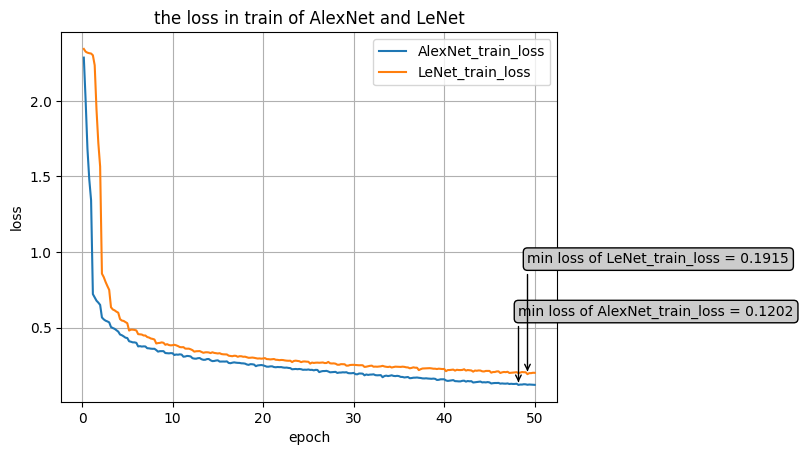

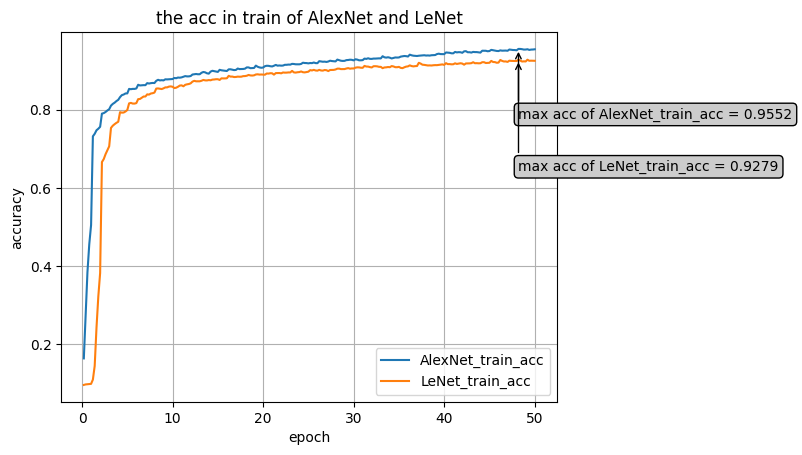

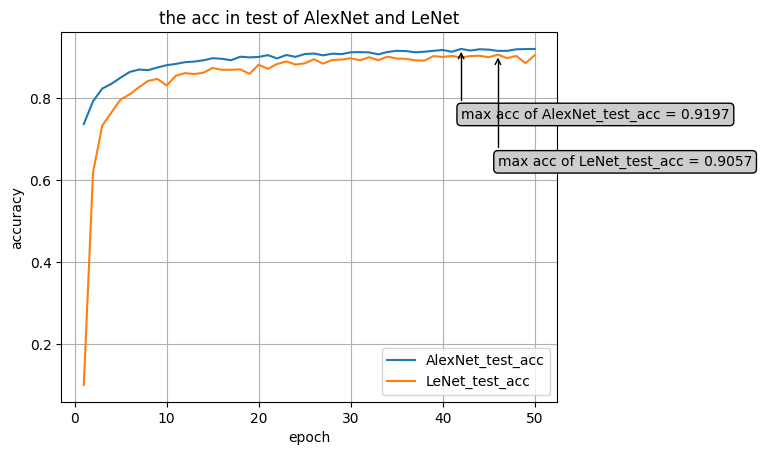

In [2]:
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('AlexNet_epoch_train', 'AlexNet_train_loss'),
                         ('LeNet_epoch_train', 'LeNet_train_loss')],
             title='the loss in train of AlexNet and LeNet')
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('AlexNet_epoch_train', 'AlexNet_train_acc'),
                         ('LeNet_epoch_train', 'LeNet_train_acc')],
             title='the acc in train of AlexNet and LeNet')
draw_figures(pth = os.path.join(pth, 'ch7_01_eval.csv'),
             label_list=[('AlexNet_epoch_test', 'AlexNet_test_acc'),
                         ('LeNet_epoch_test', 'LeNet_test_acc')],
             title='the acc in test of AlexNet and LeNet')

使用 `PyPTO` 编程进行验证：

**训练:**

In [ ]:
AlexNet_pypto = Models.AlexNet_pypto()
LeNet_pypto = Models.LeNet_pypto()
train_loader, test_loader = load_data_fashion_mnist(batch_size=128)
train_models(LeNet_pypto, train_loader, test_loader, epochs=50, lr=0.9, net_type='LeNet_pypto', csv_prefix='ch7_01')
train_loader, test_loader = load_data_fashion_mnist(batch_size=128, resize=224)
train_models(AlexNet_pypto, train_loader, test_loader, epochs=50, lr=0.01, net_type='AlexNet_pypto', csv_prefix='ch7_01')

[LeNet_pypto] |████████████████████| 100.0% epoch 50/50 train_loss=0.2073 ██████░░ ↑ train_acc=0.9222 ███████░ → test_acc=0.8901 ███████░ ↓ et=09:24


**展示:**

In [ ]:
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('AlexNet_pypto_epoch_train', 'AlexNet_pypto_train_loss'),
                         ('LeNet_pypto_epoch_train', 'LeNet_pypto_train_loss')],
             title='the loss in train of AlexNet_pypto and LeNet_pypto')
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('AlexNet_pypto_epoch_train', 'AlexNet_pypto_train_acc'),
                         ('LeNet_pypto_epoch_train', 'LeNet_pypto_train_acc')],
             title='the acc in train of AlexNet_pypto and LeNet_pypto')
draw_figures(pth = os.path.join(pth, 'ch7_01_eval.csv'),
             label_list=[('AlexNet_pypto_epoch_test', 'AlexNet_pypto_test_acc'),
                         ('LeNet_pypto_epoch_test', 'LeNet_pypto_test_acc')],
             title='the acc in test of AlexNet_pypto and LeNet_pypto')

---
## 练习 7.1.2

AlexNet对Fashion-MNIST数据集来说可能太复杂了。
1. 尝试简化模型以加快训练速度，同时确保准确性不会显著下降。
1. 设计一个更好的模型，可以直接在$28 \times 28$图像上工作。

### 解答

&emsp;&emsp;AlexNetSimple模型相比AlexNet模型，首个卷积层使用3*3的卷积核，相比11*11的卷积核能更好的保留28\*28图片的特征。同时减少卷积层数量，降低模型的复杂程度。因为AlexNet模型本身是对1000分类做的优化，而我们所用的数据集是`fashion-mnist`，类别为10，并非1000。所以可以适当的降低线性层的神经元数量，加快模型的训练时间。

&emsp;&emsp;简化后的设计相比原有网络在准确率上下降了3个百分点左右，但网络的运行效率大大增加，运行时间较原网络提升了约40%左右，基本保持了原有的精度。

使用 `torch` 编程进行验证：

In [ ]:
class AlexNetSimple(nn.Module):
    def __init__(self, in_channels=1, num_classes=10) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),  
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 2048),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(1024, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)

**训练:**

In [ ]:
train_loader, test_loader = load_data_fashion_mnist(batch_size=128)
AlexSimple = Models.AlexNetSimple()
train_models(AlexSimple, train_loader, test_loader, epochs=50, lr=0.01, net_type='AlexSimple', csv_prefix='ch7_01')

**展示:**

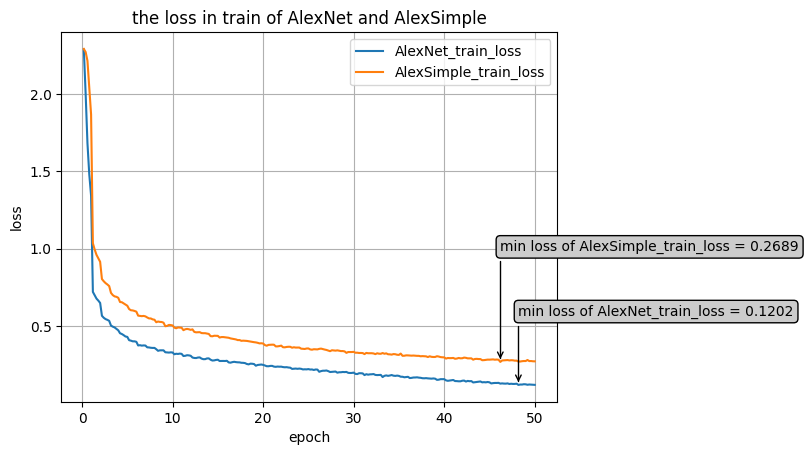

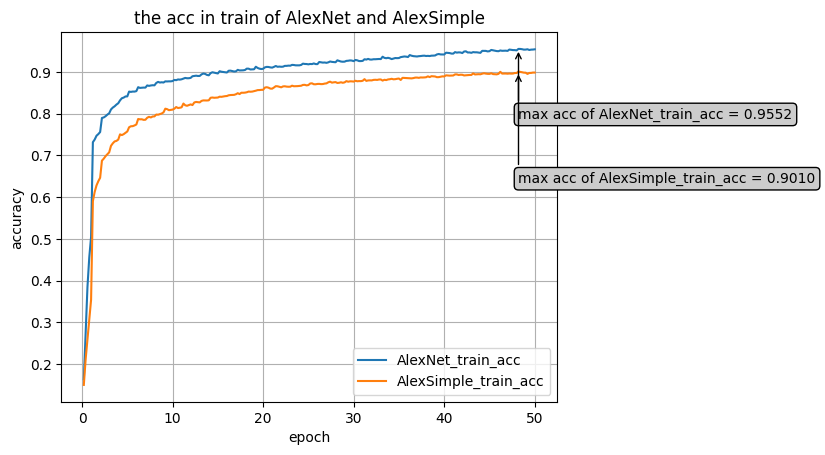

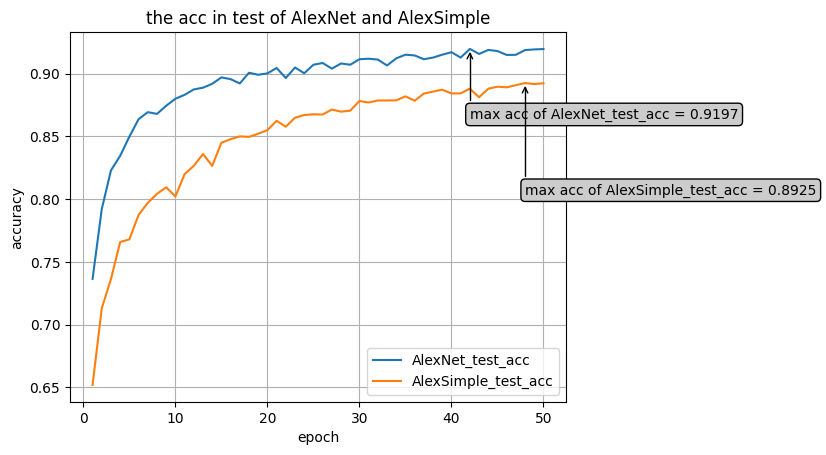

In [3]:
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('AlexNet_epoch_train', 'AlexNet_train_loss'),
                        ('AlexSimple_epoch_train', 'AlexSimple_train_loss')],
             title='the loss in train of AlexNet and AlexSimple')
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('AlexNet_epoch_train', 'AlexNet_train_acc'),
                         ('AlexSimple_epoch_train', 'AlexSimple_train_acc')],
             title='the acc in train of AlexNet and AlexSimple')
draw_figures(pth = os.path.join(pth, 'ch7_01_eval.csv'),
             label_list=[('AlexNet_epoch_test', 'AlexNet_test_acc'),
                         ('AlexSimple_epoch_test', 'AlexSimple_test_acc')],
             title='the acc in test of AlexNet and AlexSimple')

使用 `PyPTO` 编程进行验证：

**训练:**

In [ ]:
AlexSimple_pypto = Models.AlexNetSimple_pypto()
train_models(AlexSimple_pypto, train_loader, test_loader, epochs=50, lr=0.01, net_type='AlexSimple_pypto', csv_prefix='ch7_01')

**展示:**

In [ ]:
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('AlexNet_pypto_epoch_train', 'AlexNet_pypto_train_loss'),
                         ('AlexSimple_pypto_epoch_train', 'AlexSimple_pypto_train_loss')],
             title='the loss in train of AlexNet_pypto and AlexSimple_pypto')
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('AlexNet_pypto_epoch_train', 'AlexNet_pypto_train_acc'),
                         ('AlexSimple_pypto_epoch_train', 'AlexSimple_pypto_train_acc')],
             title='the acc in train of AlexNet_pypto and AlexSimple_pypto')
draw_figures(pth = os.path.join(pth, 'ch7_01_eval.csv'),
             label_list=[('AlexNet_pypto_epoch_test', 'AlexNet_pypto_test_acc'),
                         ('AlexSimple_pypto_epoch_test', 'AlexSimple_pypto_test_acc')],
             title='the acc in test of AlexNet_pypto and AlexSimple_pypto')

---
## 练习 7.1.3

修改批量大小，并观察模型精度和GPU显存变化。

### 解答

&emsp;&emsp;分别对比`batch_size`为64、128、512时的模型精度和GPU显存变化。

&emsp;&emsp;在上面的实验中可以看出，batch_size越大运行所需要的显存就越多，模型的精度也会降低。

&emsp;&emsp;在一定范围内，增加batchsize有助于收敛的稳定性，但是随着batchsize的增加，模型的性能会下降。

&emsp;&emsp;较小的batch_size通常可以提供更好的泛化能力，因为它引入了一定的噪声，有助于模型避免陷入局部最优解。但其缺点是由于噪声较大，训练过程可能不够稳定，需要更多的迭代次数才能收敛。

&emsp;&emsp;较大的batch_size可以减少模型更新的次数，有助于训练过程的稳定性。同样其也存在一定的缺点：大批量可能会降低模型的泛化能力，因为它减少了噪声的引入，有时可能导致模型过早陷入局部最优。

&emsp;&emsp;通常batch_size越大，一次迭代中处理的数据量就越大，因此需要更多的内存或显存来存储这些数据及其梯度。对于有限的硬件资源，这可能成为限制因素。

使用 `torch` 编程进行验证：

**网络结构 (AlexNet):**

In [ ]:
AlexNet = nn.Sequential(
    nn.Conv2d(1, 96, kernel_size=11, stride=4, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(),
    nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    nn.Linear(6400, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 4096), nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4096, 10))

**训练 (3 档 batch_size):**

In [ ]:
lr, num_epochs = 0.01, 10

# batch_size=64, 显存占用: 3.74GB, loss 0.274, train acc 0.898, test acc 0.895
batch_size = 64
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)
train_ch6(AlexNet, train_iter, test_iter, num_epochs, lr, 'npu:0')
# batch_size=128, 显存占用: 7.93GB, loss 0.324, train acc 0.880, test acc 0.886
batch_size = 128
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)
train_ch6(AlexNet, train_iter, test_iter, num_epochs, lr, 'npu:0')
# batch_size=512, 显存占用: 7.93GB+, loss 0.504, train acc 0.811, test acc 0.823
batch_size = 512
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)
train_ch6(AlexNet, train_iter, test_iter, num_epochs, lr, 'npu:0')

使用 `PyPTO` 编程进行验证：

**网络结构 (AlexNet PyPTO):**

In [ ]:
AlexNet_pypto = nn.Sequential(
    PyPTOConv2d(1, 96, kernel_size=11, stride=4, padding=1, bias=True, device=device), nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=3, stride=2),
    PyPTOConv2d(96, 256, kernel_size=5, padding=2, bias=True, device=device), nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=3, stride=2),
    PyPTOConv2d(256, 384, kernel_size=3, padding=1, bias=True, device=device), nn.ReLU(),
    PyPTOConv2d(384, 384, kernel_size=3, padding=1, bias=True, device=device), nn.ReLU(),
    PyPTOConv2d(384, 256, kernel_size=3, padding=1, bias=True, device=device), nn.ReLU(),
    PyPTOMaxPool2d(kernel_size=3, stride=2),
    nn.Flatten(),
    PyPTOLinear(6400, 4096), nn.ReLU(),
    PyPTODropout(p=0.5),
    PyPTOLinear(4096, 4096), nn.ReLU(),
    PyPTODropout(p=0.5),
    PyPTOLinear(4096, 10)).to(device)

**训练 (3 档 batch_size):**

In [ ]:
# batch_size=64 PyPTO
batch_size = 64
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)
train_ch6(AlexNet_pypto, train_iter, test_iter, num_epochs, lr, 'npu:0')
# batch_size=128 PyPTO
batch_size = 128
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)
train_ch6(AlexNet_pypto, train_iter, test_iter, num_epochs, lr, 'npu:0')
# batch_size=512 PyPTO
batch_size = 512
train_iter, test_iter = load_data_fashion_mnist(batch_size, resize=224)
train_ch6(AlexNet_pypto, train_iter, test_iter, num_epochs, lr, 'npu:0')

---
## 练习 7.1.4

分析AlexNet的计算性能。
1. 在AlexNet中主要是哪部分占用显存？
1. 在AlexNet中主要是哪部分需要更多的计算？
1. 计算结果时显存带宽如何？

### 解答

&emsp;&emsp;我们首先使用`torchinfo`中的`summary()`函数观察 AlexNet 的网络结构

```python
AlexNet = Models.AlexNet()
torchinfo.summary(AlexNet, (1, 1, 224, 224))
```

**问题1**

&emsp;&emsp;首先，对于训练过程的显存占用，主要分为两部分，一部分为网络参数占用显存，另一部分为在传播过程中模型所占用显存。

&emsp;&emsp;对于网络参数占据显存：在AlexNet中，网络参数占据最多显存的层是是我们后面的**全连接层**，在AlexNet中，网络参数的显存主要被以下两部分占用（relu等没有参数的层相比之下的显存占据量可以忽略）：

* 卷积层（Convolutional Layers）：这些层主要储存权重（卷积核）和特征图（feature maps）。每个卷积层包含多个卷积核，每个核都有自己的权重参数，而特征图则是每层的输出。由于卷积层通常使用更多的卷积核和较大的特征图，因此它们往往占据较多显存。
  $$
  \text{Memory} =  \text{ Number ~ of ~ Filters} \times (\text{Filter~Size} \times \text{Input~Channels} + 1) \times 4 \text{bytes}
  $$

* 全连接层（Fully Connected Layers）：这些层储存连接网络各层的权重。
  $$
  \text{Memory}=   \text{Number~of~Input} \times (\text{Number~of~Output} + 1) \times 4 \text{bytes} 
  $$
&emsp;&emsp;乘4 bytes（此处默认每个网络参数都是`float32`的类型）之前，其得到的值也就是该层参数的值，这也是与上面的`summary()`对应的.

&emsp;&emsp;对于模型占据显存：我们可以这么来看，不论是前向传播还是反向传播过程，输入每经过一层网络（不论是`Conv2d` `linear` `dropout`），都会缓存下经过这一次网络的输出。

&emsp;&emsp;以AlexNet为例，训练过程如下：
1. 首先对于`(1, 1, 224, 224)`的输入，其内存占用为$1\times1\times224\times224\times4\text{byte}=0.191$，就是这里的`Input size (MB): 0.20`；
2. 经过第一层`Conv2d`后输出`(1, 96, 54, 54)`，其内存占用为$1\times96\times54\times54\times4\text{byte}$；
3. 经过非参数层`ReLu`后输出`(1, 96, 54, 54)`，其内存占用为$1\times96\times54\times54\times4\text{byte}$。
4. 以此类推，可以得到整个网络模型大小约为`summary()`中的`Forward/backward pass size (MB): 4.87`

&emsp;&emsp;那么对于整个训练过程的内存占用，我们可以这么计算：

&emsp;&emsp;在训练过程中，以AlexNet使用`SGD`化器并结合`momentum`算法，`batch_size=128`
* 参数显存`Params size (MB): 187.06`，总训练过程占用为$187.06\times3$（`SGD`和`momentum`各需要一份参数）
* 模型显存为$~4.87\times128\times2 ~\text{MB}$，(乘2是因为有**前向和反向**两个过程)
* 两者之和则是网络占用显存总量

**问题2**

&emsp;&emsp;在这个模型中，需要更多计算的层主要是全连接层。全连接层的计算量与输入和输出的维度相关，因此输入维度为6400的第一层全连接层和输出维度为4096的第二层全连接层需要更多的计算。这两个全连接层的计算量是其他卷积层的数倍，也是整个模型计算量的瓶颈。因此，在实际应用中，可以考虑减少全连接层的数量和神经元个数，以减少计算量并提高模型的运行速度。
* 卷积层运算：
$$
\text{Total ~ Cost}=\text{Number ~ of ~ Filters}\times \text{Filter ~ Size}\times \text{Input ~ Channels}\times \text{Output ~ Height}\times \text{Output ~ Width}
$$
* 全连接层运算：
$$
\text{Total ~ Cost}=\text{Input ~ Neurons}\times \text{Output ~ Neurons}
$$

**问题3**

&emsp;&emsp;此问题，在英文原版教材中的提问为：
>How does the memory (read and write bandwidth, latency, size) affect computation? Is there any difference in its effects for training and inference?

&emsp;&emsp;我们以此问题给出答案：
1. 读写带宽

&emsp;&emsp;训练阶段：在训练期间，高带宽是至关重要的，因为它允许GPU和内存之间更快的数据传输。在处理大型数据集和执行批处理时，这一点尤其重要。高带宽确保GPU快速接收数据，减少空闲时间，加快整体训练过程。

&emsp;&emsp;推断阶段：虽然高带宽在推断阶段也有好处，但其影响通常不如训练阶段明显。这是因为推理通常涉及一次处理一个输入(与训练中的批量处理相反)，并且每个实例的数据大小更小。

2. 延迟

&emsp;&emsp;训练阶段：低延迟可以显著提高训练速度。在训练过程中，需要频繁地访问和更新数据和梯度。高延迟会减慢这些操作，导致更长的训练时间。

&emsp;&emsp;推理阶段：延迟在推理期间也很重要（但仿佛没那么重要），因为它会影响网络的响应时间。

3. 内存大小

&emsp;&emsp;训练阶段：更大的内存大小有利于训练，因为它允许更大的批处理大小，这可以提高训练过程的效率和稳定性。此外，更大的内存可以容纳更复杂的模型或具有更大输入数据大小的模型。

&emsp;&emsp;推理阶段：在推理阶段，内存大小没有训练阶段那么重要，但它仍然很重要，特别是在部署大型模型时。在内存有限的场景中(比如在移动设备上)，可能需要更小的模型或模型压缩技术。

---
## 练习 7.1.5

将dropout和ReLU应用于LeNet-5，效果有提升吗？再试试预处理会怎么样？

### 解答

&emsp;&emsp;改进后的LeNet结构如下，我们定义为LeNetPro，我们在原有基础上，在每个卷积层后添加了`ReLU()`，并且在全连接层我们加入了`Dropout()`

&emsp;&emsp;将`Dropout`和`ReLU`应用于`LeNet`之后会提升其性能：

- `Dropout`可以防止过拟合，避免神经元之间的过度共适应，从而提高网络的泛化能力。可以看出在加入`Dropout`之后，`test_acc`相比原版网络有所提升，说明网络的泛化能力得到了提高。 `Dropout`作为一种正则化技术，它在训练过程中随机地"丢弃"（即将输出置为零）神经元的一部分。这有助于模型学会不依赖于任何单个神经元，从而减少对特定训练数据的过拟合，同时通过引入噪声（即丢弃神经元），`Dropout`迫使网络在更宽泛的数据表示上进行学习，从而增强模型的泛化能力。

- `ReLU`可以增加网络的非线性，从而提高其表示能力。用`ReLU`替代`Sigmoid`之后，需要把模型的学习率调低，模型可以更加快速的收敛。

使用 `torch` 编程进行验证：

In [ ]:
class LeNetPro(nn.Module):
    def __init__(self, in_channels=1, num_classes=10) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.num_classes = num_classes
        self.net = nn.Sequential(nn.Conv2d(self.in_channels, 6, kernel_size=5, padding=2),
                                 nn.ReLU(),
                                 nn.AvgPool2d(kernel_size=2, stride=2),
                                 nn.Conv2d(6, 16, kernel_size=5), 
                                 nn.ReLU(),
                                 nn.AvgPool2d(kernel_size=2, stride=2),
                                 nn.Flatten(),
                                 nn.Linear(16 * 5 * 5, 120), 
                                 nn.ReLU(),
                                 nn.Dropout(p=0.5),
                                 nn.Linear(120, 84),
                                 nn.ReLU(),  
                                 nn.Dropout(p=0.5),
                                 nn.Linear(84, self.num_classes))
    def forward(self, x):
        return self.net(x)

**训练:**

In [ ]:
LeNet = Models.LeNet()
train_loader, test_loader = load_data_fashion_mnist(batch_size=128)
train_models(LeNet, train_loader, test_loader, epochs=50, lr=0.1, net_type='LeNet_0.1_', csv_prefix='ch7_01')
LeNetPro = Models.LeNetPro()
train_loader, test_loader = load_data_fashion_mnist(batch_size=128)
train_models(LeNetPro, train_loader, test_loader, epochs=50, lr=0.1, net_type='LeNetPro', csv_prefix='ch7_01')

**展示:**

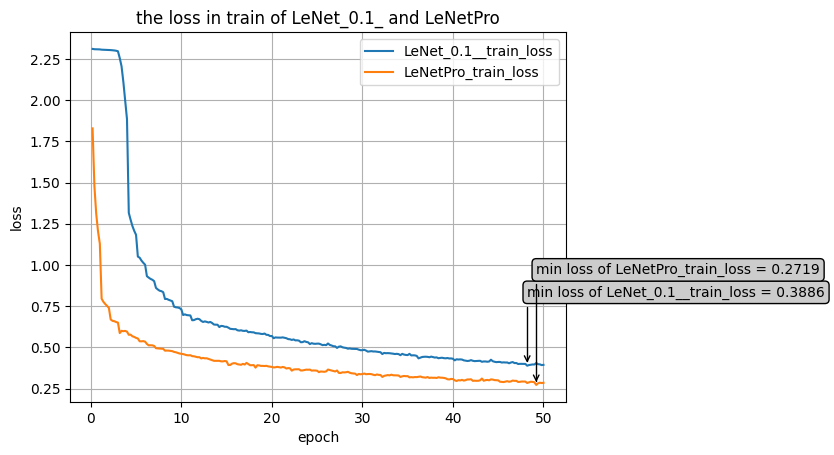

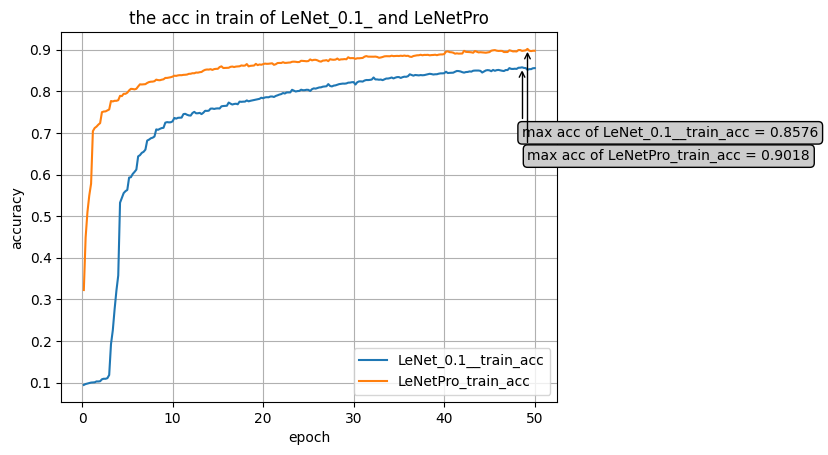

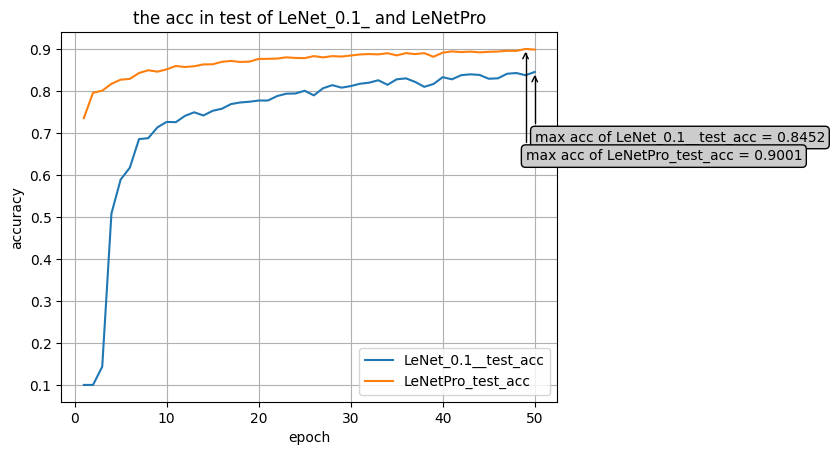

In [4]:
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('LeNet_0.1__epoch_train', 'LeNet_0.1__train_loss'),
                         ('LeNetPro_epoch_train', 'LeNetPro_train_loss')],
             title='the loss in train of LeNet_0.1_ and LeNetPro')
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('LeNet_0.1__epoch_train', 'LeNet_0.1__train_acc'),
                         ('LeNetPro_epoch_train', 'LeNetPro_train_acc')],
             title='the acc in train of LeNet_0.1_ and LeNetPro')
draw_figures(pth = os.path.join(pth, 'ch7_01_eval.csv'),
             label_list=[('LeNet_0.1__epoch_test', 'LeNet_0.1__test_acc'),
                         ('LeNetPro_epoch_test', 'LeNetPro_test_acc')],
             title='the acc in test of LeNet_0.1_ and LeNetPro')

使用 `PyPTO` 编程进行验证：

**训练:**

In [ ]:
LeNet_0_1_pypto = Models.LeNet_pypto()
LeNetPro_pypto = Models.LeNetPro_pypto()
train_loader, test_loader = load_data_fashion_mnist(batch_size=128)
train_models(LeNet_0_1_pypto, train_loader, test_loader, epochs=50, lr=0.1, net_type='LeNet_0.1_pypto', csv_prefix='ch7_01')
train_models(LeNetPro_pypto, train_loader, test_loader, epochs=50, lr=0.1, net_type='LeNetPro_pypto', csv_prefix='ch7_01')

**展示:**

In [ ]:
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('LeNet_0.1_pypto_epoch_train', 'LeNet_0.1_pypto_train_loss'),
                         ('LeNetPro_pypto_epoch_train', 'LeNetPro_pypto_train_loss')],
             title='the loss in train of LeNet_0.1_pypto and LeNetPro_pypto')
draw_figures(pth = os.path.join(pth, 'ch7_01.csv'),
             label_list=[('LeNet_0.1_pypto_epoch_train', 'LeNet_0.1_pypto_train_acc'),
                         ('LeNetPro_pypto_epoch_train', 'LeNetPro_pypto_train_acc')],
             title='the acc in train of LeNet_0.1_pypto and LeNetPro_pypto')
draw_figures(pth = os.path.join(pth, 'ch7_01_eval.csv'),
             label_list=[('LeNet_0.1_pypto_epoch_test', 'LeNet_0.1_pypto_test_acc'),
                         ('LeNetPro_pypto_epoch_test', 'LeNetPro_pypto_test_acc')],
             title='the acc in test of LeNet_0.1_pypto and LeNetPro_pypto')

---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#](https://datawhalechina.github.io/d2l-ai-solutions-manual/#)